# Yapısal Ağ Önem Endeksi (Structural Network Importance Index - SNII) — Uçtan Uca Analiz (v2)

Bu defter, 62 sektörlük ara girdi (intermediate input) akış matrisinden **SNII (Yapısal Ağ Önem Endeksi)**
kurar. `SNII_Analysis_Prompt.md` dosyasındaki v2 talimatlarını uygular ve v1'deki üç temel sorunu düzeltir:

- **P1 — Boyut (sector size) kirliliği:** merkezilik ölçütleri artık ham akış (z_ij) yerine
  **boyuttan arındırılmış** (size-normalized) katsayı matrisleri (`A`, `B`) üzerinde hesaplanıyor.
- **P2 — Entropi ağırlıklandırmasının bir boyutu ezmesi:** birincil endeks artık dört kavramsal boyutu
  **eşit ağırlıkla (0.25)** birleştiren `SNII_DIM`; düz entropi-TOPSIS sadece karşılaştırma amaçlı tutuluyor.
- **P3 — Kalıcı çoklu doğrusal bağlantı (multicollinearity):** gösterge seçiminde eşik **|Spearman| ≥ 0.85**
  ve **VIF < 5** şartı zorunlu kılınıyor.

Tüm çıktı dosyaları, üretim/okuma sırasına göre **numaralandırılmıştır** (`1_...`, `2_...`, ...).
Her analiz adımından önce **ne, nasıl ve neden** yapıldığını açıklayan Türkçe notlar bulunmaktadır.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

from NetworkCalculations import NetworkCalculations
from SNIIIndex import SNIIComposite, DIMENSIONS, ALL_INDICATORS

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

DATA_FILE = "1-IntermediateInputs.xlsx"
print("Ortam hazır. Rastgelelik tohumu (seed) =", RANDOM_SEED)


Ortam hazır. Rastgelelik tohumu (seed) = 42


## 1. Üretim Ağının Kurulması (Section 2)

**Ne:** `1-IntermediateInputs.xlsx` dosyasından 62×62 ham ara girdi akış matrisi `Z` ve her sektörün
toplam üretimi (`Total Output`) okunur. Bunlardan iki **boyuttan arındırılmış** matris türetilir:

- **Teknik katsayı matrisi `A`** (talep yönlü): `a_ij = z_ij / X_j` — sektör *j*'nin birim üretimi için
  sektör *i*'den ne kadar girdi kullandığını gösterir (Leontief geleneği).
- **Ghosh dağıtım matrisi `B`** (arz yönlü): `b_ij = z_ij / X_i` — sektör *i*'nin ürettiği çıktının ne kadarının
  sektör *j*'ye satıldığını gösterir (Ghosh geleneği).

**Nasıl:** `NetworkCalculations` sınıfı Excel dosyasını okur, `A` ve `B` matrislerini hesaplar ve
kenar ağırlıkları bu katsayılardan oluşan yönlü ağırlıklı `networkx.DiGraph` nesnelerini kurar
(kenar yönü: tedarikçi *i* → alıcı *j*).

**Neden:** Ham akışlar (`z_ij`) üzerinde hesaplanan merkezilikler mekanik olarak sektör büyüklüğüyle
orantılı çıkar (P1 sorunu). `A`/`B` ile normalize etmek, "büyük olduğu için önemli görünme" etkisini
ortadan kaldırıp gerçek **yapısal** (structural) önemi ortaya çıkarır.


In [2]:
net = NetworkCalculations(DATA_FILE)

print("Sektör sayısı:", net.n)
print("Z (ham akış) boyutu:", net.Z.shape)
print("A (teknik katsayı) örneklem:")
display(net.A.iloc[:5, :5])
print("B (Ghosh dağıtım) örneklem:")
display(net.B.iloc[:5, :5])


Sektör sayısı: 62
Z (ham akış) boyutu: (62, 62)
A (teknik katsayı) örneklem:


,sec1,sec2,sec3,sec4,sec5
sec1,0.168077,0.005372,0.002862,2.612856e-03,0.279824
sec2,0.000728,0.024668,0.001708,1.554894e-07,0.000604
sec3,0.000000,0.000000,0.019605,7.078394e-07,0.000081
sec4,0.001524,0.002854,0.000731,3.811675e-02,0.002584
sec5,0.027917,0.000677,0.031346,2.115233e-03,0.132556


B (Ghosh dağıtım) örneklem:


,sec1,sec2,sec3,sec4,sec5
sec1,0.168077,0.000130,0.000069,0.001391,0.304096
sec2,0.030054,0.024668,0.001704,0.000003,0.027111
sec3,0.000000,0.000000,0.019605,0.000016,0.003623
sec4,0.002862,0.000130,0.000033,0.038117,0.005272
sec5,0.025688,0.000015,0.000697,0.001037,0.132556


**Bağlantılılık kontrolü (connectivity guard, Section 3 & 6.9):** Özvektör merkeziliği (eigenvector
centrality) yalnızca **kuvvetle bağlı (strongly connected)** bir grafta matematiksel olarak iyi tanımlıdır
(Perron-Frobenius teoremi). Bu nedenle önce grafın kuvvetle bağlı olup olmadığı kontrol edilir; değilse
en büyük kuvvetle bağlı bileşene (largest SCC) daraltılır ve bu durum açıkça raporlanır — hiçbir zaman
sessizce geçersiz bir skor döndürülmez.


In [3]:
connectivity = net.connectivity_report()
for k, v in connectivity.items():
    print(f"{k}: {v}")


strongly_connected: True
eigenvector_method: full graph (strongly connected)
density: 0.9981491274457959
edge_count: 3775
node_count: 62


## 2. Yedi Yapısal Gösterge — Dört Kavramsal Boyut (Section 3)

**Ne:** Dört boyutta toplam yedi aday gösterge hesaplanır:

| Boyut | Gösterge(ler) | Anlamı |
|---|---|---|
| D1 — Doğrudan bağlantı gücü | `backward_linkage`, `forward_linkage` | Leontief/Ghosh tersi üzerinden geriye/ileriye bağlantı |
| D2 — Sistemik gömülülük | `eigenvector_centrality`, `pagerank` | Önemli komşulara bağlı olma / ağ genelinde etki |
| D3 — Köprü/yayılma rolü | `betweenness_centrality` | Sektörler arası dolaylı akışların üzerinden geçtiği düğüm olma |
| D4 — Arz-dağıtım yönelimi | `hub_score`, `authority_score` | HITS: geniş dağıtım yapan (hub) / geniş talep gören (authority) |

**Nasıl:** `NetworkCalculations.general_network_results()` yedi göstergeyi de `A` (ya da yönlü olduğu
yerlerde `B`) üzerinde hesaplayıp min–max ile [0,1] aralığına ölçekler ve 62×7 bir tabloda birleştirir.

**Neden:** Tek bir merkezilik ölçütü ağın yalnızca bir yönünü yakalar (ör. PageRank etkiyi, betweenness
köprü rolünü ölçer). Dört boyutlu bir çerçeve, endeksin sonradan (Bölüm 4) tek bir istatistiksel
boyuta (ör. entropiyle en yüksek çeşitliliğe sahip boyuta) kilitlenmesini önler.


In [4]:
network_results = net.general_network_results()
print("network_results boyutu:", network_results.shape)
display(network_results.head(10))


network_results boyutu: (62, 7)


,backward_linkage,forward_linkage,eigenvector_centrality,pagerank,betweenness_centrality,hub_score,authority_score
sector,,,,,,,
sec1,0.264275,0.399122,0.161260,0.058999,0.018889,0.299393,0.154713
sec2,0.099784,0.681779,0.146179,0.132304,0.016667,0.062068,0.085915
sec3,0.214073,0.000000,0.293341,0.146750,0.000000,0.000000,0.231762
sec4,0.130330,0.987403,0.144294,0.083042,0.033333,0.413892,0.133292
sec5,0.605889,0.205657,0.513547,0.308273,0.345556,0.258692,0.512717
sec6,0.615791,0.253487,0.372888,0.189383,0.004444,0.148489,0.336495
sec7,0.596359,0.578266,0.559687,0.363579,0.046667,0.105157,0.472414
sec8,0.547327,0.523666,0.479047,0.342808,0.084444,0.233989,0.348345
sec9,0.635784,0.671410,0.832887,0.499611,0.076667,0.055524,0.522357


**Karşılaştırma artefaktı (P1 kanıtı, Section 3):** Aynı dört merkezilik, karşılaştırma amacıyla
**ham akışlar (`z_ij`)** üzerinde de hesaplanır. Aşağıdaki adımda bu ham-akış versiyonları ile
katsayı-tabanlı (coefficient-based) versiyonların sektör büyüklüğüyle korelasyonu karşılaştırılacak
(Bölüm 5) — beklenti, katsayı-tabanlı ölçütlerin büyüklükle çok daha zayıf ilişkili olmasıdır.


In [5]:
raw_flow_comparison = net.raw_flow_comparison()
display(raw_flow_comparison.head())


,eigenvector_centrality_raw,pagerank_raw,betweenness_centrality_raw,hub_score_raw,authority_score_raw
sector,,,,,
sec1,0.142786,0.020419,0.008197,0.182534,0.016885
sec2,0.002313,0.002930,0.000000,0.000694,0.000345
sec3,0.004317,0.003082,0.000000,0.000059,0.000505
sec4,0.048148,0.011196,0.003825,0.047852,0.008763
sec5,0.402442,0.044916,0.172131,0.016279,0.213706


### Çıktı 1: `1_network_candidate_indicators.xlsx`

**Ne:** Yedi göstergenin ham/normalize halleri ile ham-akış karşılaştırma tablosu tek bir Excel
dosyasında saklanır (Section 9, Section 6.11 — "tüm ham göstergeler sonraki hipotez testleri için
korunmalı").

**Neden numaralandırma:** Kullanıcı isteği doğrultuğunda, bu defterdeki üretim/okunma sırasına göre
tüm çıktı dosyaları `1_`, `2_`, `3_`, ... öneki ile numaralandırılır.


In [6]:
with pd.ExcelWriter("1_network_candidate_indicators.xlsx", engine="openpyxl") as writer:
    network_results.to_excel(writer, sheet_name="coefficient_based_indicators")
    raw_flow_comparison.to_excel(writer, sheet_name="raw_flow_comparison")
    net.total_output.to_frame().to_excel(writer, sheet_name="total_output")

print("Kaydedildi: 1_network_candidate_indicators.xlsx")


Kaydedildi: 1_network_candidate_indicators.xlsx


## 3. Üretim Ağı Görselleştirmesi (Section 7.9)

**Ne:** Yönlü üretim ağı çizilir. Düğüm büyüklüğü `eigenvector_centrality` (boyuttan arındırılmış,
yapısal önemi temsil eder), kenar kalınlığı normalize katsayı (`a_ij`) büyüklüğü ile orantılıdır.

**Nasıl:** Görsel karmaşayı azaltmak için yalnızca belirli bir eşiğin üzerindeki kenarlar çizilir
(eşik: `A` matrisinin 90. yüzdelik dilimi). Düğüm konumları `spring_layout` (Fruchterman-Reingold)
ile belirlenir; sabit `seed=42` ile tekrarlanabilirlik sağlanır.

**Neden eşikleme:** 62 sektörlü tam bağlı bir grafın (density ≈ 1) tüm kenarlarını çizmek görseli
okunmaz hale getirir; eşikleme yalnızca en güçlü ekonomik bağlantıları öne çıkarır.


Kenar eşiği (A matrisinin 90. yüzdelik dilimi): 0.01472


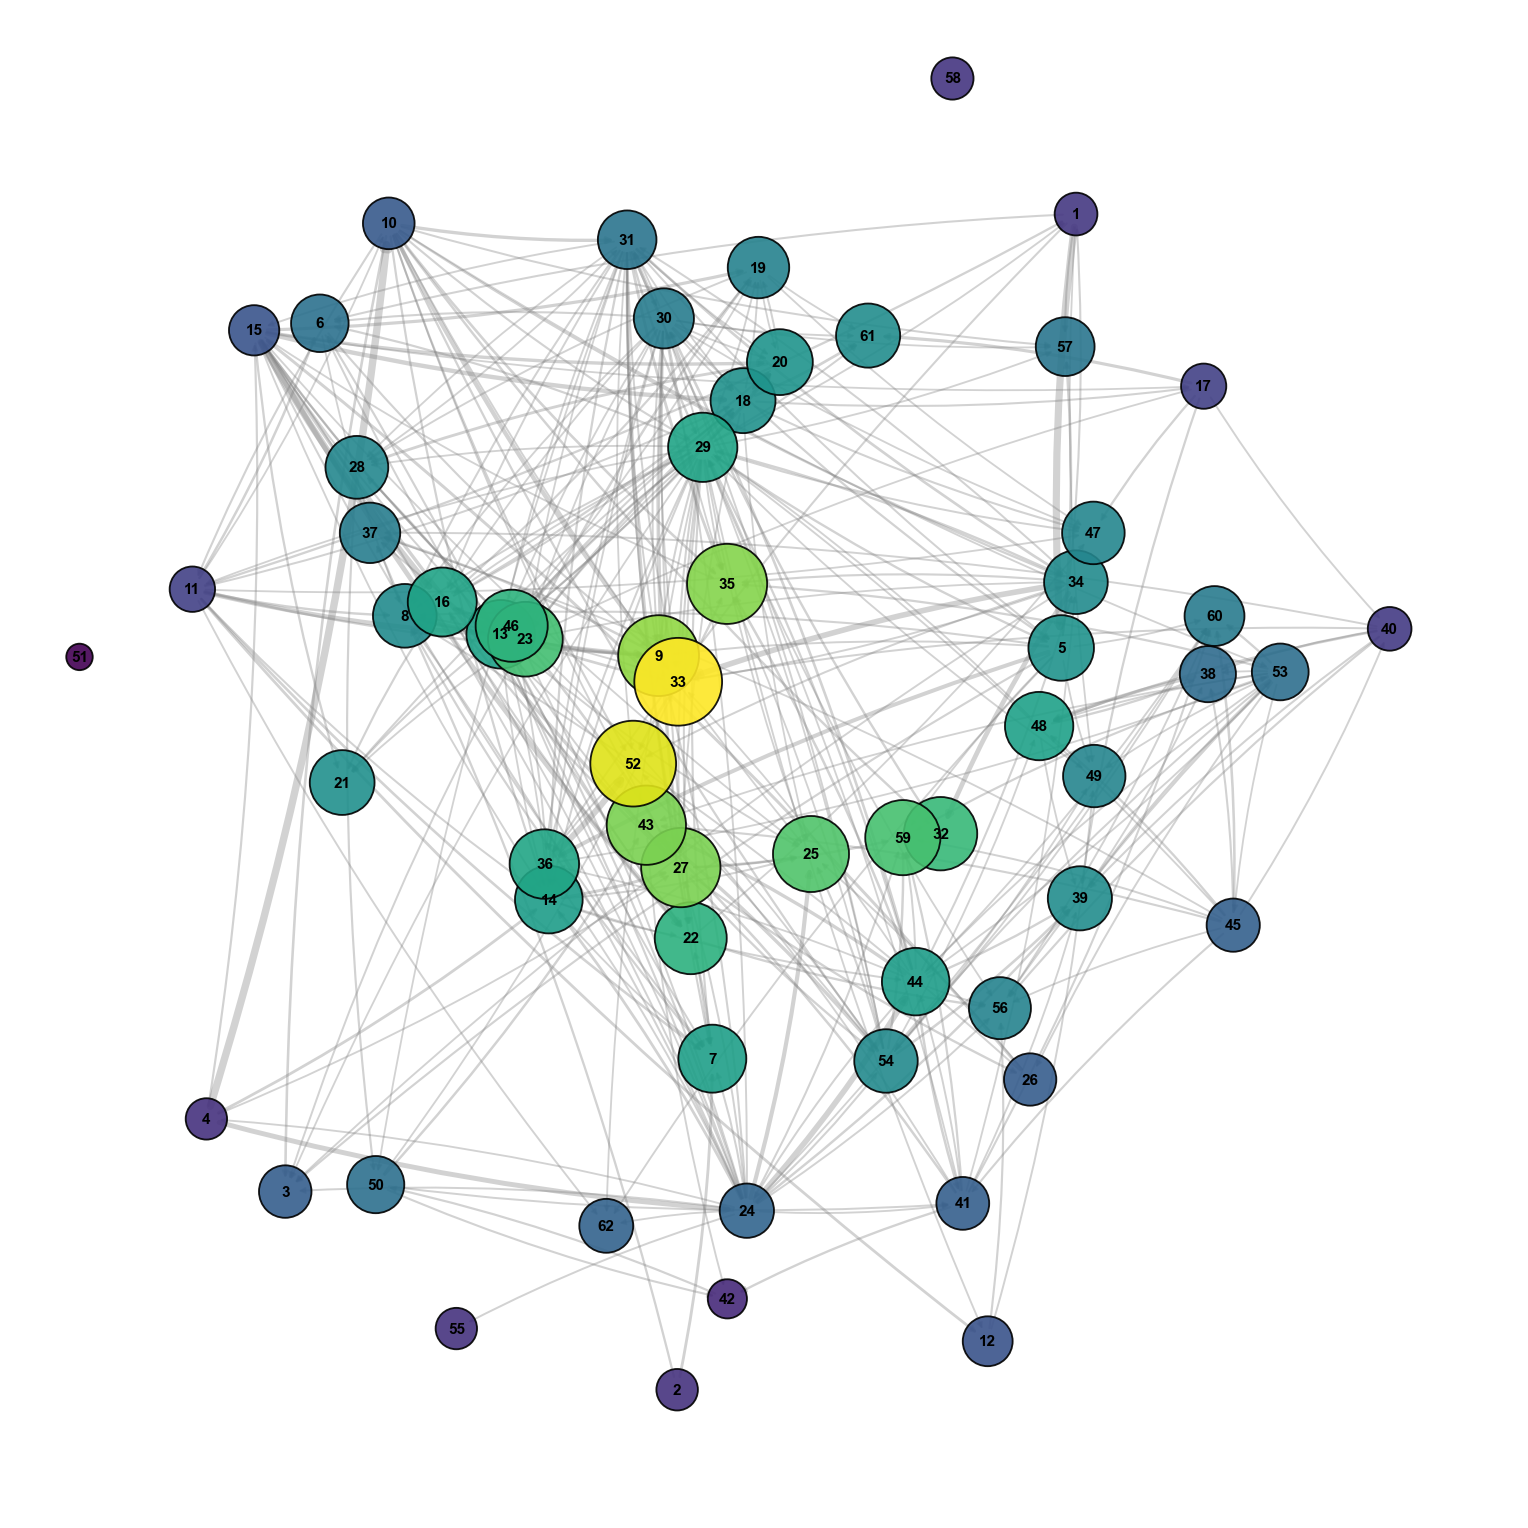

In [7]:
A = net.A
threshold = np.quantile(A.values[A.values > 0], 0.90)
print(f"Kenar eşiği (A matrisinin 90. yüzdelik dilimi): {threshold:.5f}")

G_plot = nx.DiGraph()
G_plot.add_nodes_from(net.sectors)
for u in net.sectors:
    for v in net.sectors:
        w = A.loc[u, v]
        if u != v and w >= threshold:
            G_plot.add_edge(u, v, weight=w)

eig = network_results["eigenvector_centrality"]
spring_pos = nx.spring_layout(G_plot, seed=RANDOM_SEED, k=0.6, weight="weight", iterations=200)
eig_rank = eig.reindex(net.sectors).rank(pct=True, method="average")
rng = np.random.default_rng(RANDOM_SEED)
pos = {}
for sector in net.sectors:
    x, y = spring_pos[sector]
    angle = np.arctan2(y, x) + rng.normal(0, 0.10)
    centrality_radius = 0.10 + 0.90 * (1 - eig_rank.loc[sector]) ** 0.72
    radius = np.clip(centrality_radius * rng.uniform(0.82, 1.18), 0.04, 1.0)
    pos[sector] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

fig, ax = plt.subplots(figsize=(14, 14))
node_sizes = 300 + 3000 * eig.reindex(net.sectors).values
edge_widths = [1 + 6 * (G_plot[u][v]["weight"] / A.values.max()) for u, v in G_plot.edges()]

nx.draw_networkx_nodes(G_plot, pos, node_size=node_sizes, node_color=eig.reindex(net.sectors).values,
                        cmap="viridis", alpha=0.9, edgecolors="black", linewidths=1.2, ax=ax)
nx.draw_networkx_edges(G_plot, pos, width=edge_widths, alpha=0.35, arrows=True,
                        arrowsize=8, edge_color="gray", connectionstyle="arc3,rad=0.05", ax=ax)
sector_number_labels = {sector: sector.removeprefix("sec") for sector in G_plot.nodes()}
nx.draw_networkx_labels(G_plot, pos, labels=sector_number_labels, font_size=10,
                        font_weight="bold", font_color="black", ax=ax)

ax.axis("off")
plt.tight_layout()
plt.savefig("4_network_visualization.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** Görselde büyük ve koyu renkli düğümler, ağ içinde en yüksek özvektör merkeziliğine sahip
— yani önemli sektörlere bağlı olan — sektörleri temsil eder. Kalın kenarlar, güçlü teknik-katsayı
bağlantılarını (yüksek `a_ij`) gösterir. Bu görsel, SNII'nin ardındaki ağ yapısını niteliksel olarak
doğrulamak için kullanılır.


## 4. Yedi Aday Gösterge Arası Korelasyon (Section 7.3)

**Ne:** Yedi göstergenin birbirleriyle Spearman rank korelasyonu hesaplanır.

**Nasıl:** `pandas.DataFrame.corr(method="spearman")` ile 7×7 korelasyon matrisi çıkarılıp ısı
haritası olarak çizilir.

**Neden:** Bu tablo, Bölüm 4'teki (redundancy screen) seçim algoritmasının girdisidir; hangi
göstergelerin birbirinin neredeyse kopyası olduğunu (|ρ| ≥ 0.85) görsel olarak teyit etmemizi sağlar.


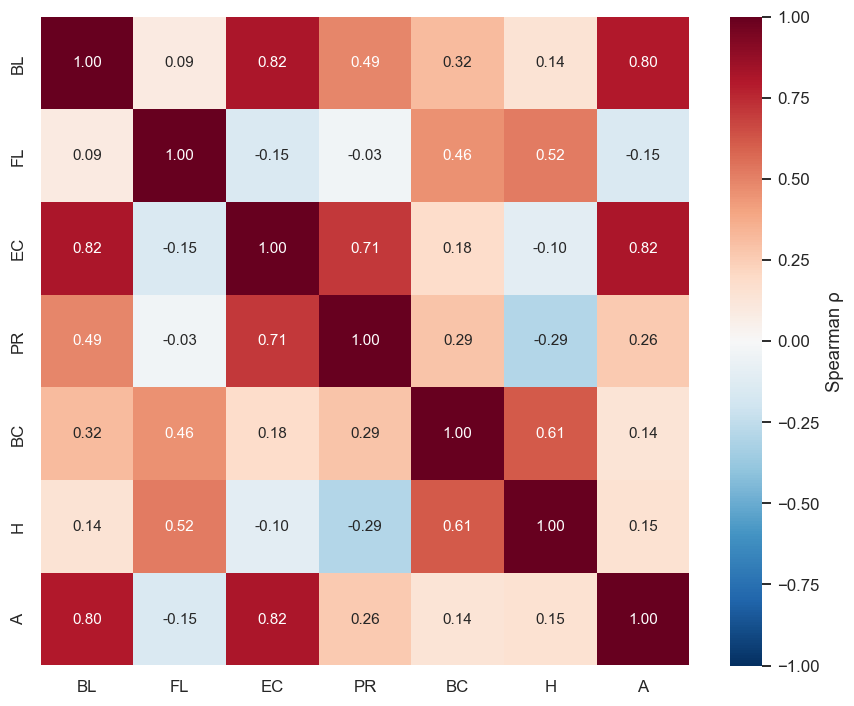

In [8]:
corr7 = network_results[ALL_INDICATORS].corr(method="spearman")
metric_abbreviations = {
    "backward_linkage": "BL", "forward_linkage": "FL",
    "eigenvector_centrality": "EC", "pagerank": "PR",
    "betweenness_centrality": "BC", "hub_score": "H",
    "authority_score": "A"
}
corr7_display = corr7.rename(index=metric_abbreviations, columns=metric_abbreviations)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr7_display, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Spearman ρ"}, ax=ax)
plt.tight_layout()
plt.savefig("5_candidate_indicator_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Gösterge Seçimi — Yedeklilik ve VIF Taraması (Section 4)

**Ne:** Yedi göstergeden, aralarında **|Spearman| ≥ 0.85** olan çiftler ve **VIF ≥ 5** olan göstergeler
elenir; her boyuttan en az bir gösterge korunur.

**Nasıl:** `SNIIComposite.select_indicators()`:
1. 7×7 Spearman matrisini ve başlangıç VIF değerlerini hesaplar.
2. Eşiği aşan en yüksek korelasyonlu çifti bulur; VIF'i daha yüksek olanı eler (eşitlikte entropi
   çeşitliliği daha düşük olan elenir — yani istatistiksel olarak daha az ayırt edici olan).
3. Bir boyutun **son kalan** göstergesi asla elenmez.
4. Eşik altı korelasyon ve tüm VIF < 5 sağlanana kadar tekrarlanır.
5. Kalan (retained) küme üzerinde **KMO** (Kaiser-Meyer-Olkin örneklem yeterliliği) ve **Bartlett
   küresellik testi** raporlanır.

**Neden eşik 0.85 (v1'deki 0.90 değil):** v1'de kullanılan gevşek eşik (0.90), kalan göstergeler
arasında hâlâ ciddi çoklu doğrusal bağlantı (VIF ≈ 8) bırakmıştı (P3 sorunu). Daha sıkı bir eşik ve
zorunlu VIF < 5 şartı, PCA/TOPSIS gibi ikincil yöntemlerin daha sağlam istatistiksel temele
oturmasını sağlar.


In [9]:
snii = SNIIComposite(network_results, total_output=net.total_output,
                      redundancy_threshold=0.85, vif_threshold=5.0)
selection = snii.select_indicators()

print("Korunan (retained) göstergeler:", selection["retained"])
print("Elenen (dropped) göstergeler:", selection["dropped"])
print()
for ind, reason in selection["reasons"].items():
    print(f"  - {ind}: {reason}")


Korunan (retained) göstergeler: ['backward_linkage', 'forward_linkage', 'pagerank', 'betweenness_centrality', 'hub_score', 'authority_score']
Elenen (dropped) göstergeler: ['eigenvector_centrality']

  - eigenvector_centrality: dropped: VIF=10.57 >= 5.0 (dimension D2_embeddedness retains other member(s))
  - backward_linkage: retained
  - forward_linkage: retained
  - pagerank: retained
  - betweenness_centrality: retained
  - hub_score: retained
  - authority_score: retained


In [10]:
print("VIF (seçim öncesi):")
display(selection["vif_before"].to_frame("VIF").round(3))
print()
print("VIF (seçim sonrası, kalan küme):")
display(selection["vif_after"].to_frame("VIF").round(3))
print()
kmo_txt = f"{selection['kmo_overall']:.3f}" if selection["kmo_overall"] is not None else "hesaplanamadı"
print(f"KMO (genel örneklem yeterliliği): {kmo_txt}")
if selection["kmo_warning"]:
    print("UYARI: KMO < 0.60 — faktör yapısı PCA için zayıf. Bu nedenle birincil endeks olarak "
          "global faktör yapısına dayanmayan SNII_DIM (boyut-dengeli endeks) kullanılacaktır.")
print(f"Bartlett küresellik testi: chi2={selection['bartlett_chi2']}, p={selection['bartlett_p']}")


VIF (seçim öncesi):


,VIF
backward_linkage,3.504
forward_linkage,1.558
eigenvector_centrality,10.566
pagerank,6.206
betweenness_centrality,1.914
hub_score,2.368
authority_score,4.738



VIF (seçim sonrası, kalan küme):


,VIF
backward_linkage,3.186
forward_linkage,1.467
pagerank,2.553
betweenness_centrality,1.860
hub_score,2.366
authority_score,2.344



KMO (genel örneklem yeterliliği): 0.386
UYARI: KMO < 0.60 — faktör yapısı PCA için zayıf. Bu nedenle birincil endeks olarak global faktör yapısına dayanmayan SNII_DIM (boyut-dengeli endeks) kullanılacaktır.
Bartlett küresellik testi: chi2=127.73168230737174, p=5.906368799798853e-20


**Yorum:** KMO değeri, göstergeler arasındaki ortak varyansın faktör analizi için ne kadar uygun
olduğunu ölçer (0.60 altı zayıf kabul edilir). Talimatın 6. maddesindeki kurala göre, KMO düşük
çıkarsa **PCA'ya değil**, global faktör yapısına ihtiyaç duymayan boyut-dengeli endekse (`SNII_DIM`)
öncelik verilir. Bu, aşağıdaki Bölüm 6'da uygulanacaktır.


### Çıktı 2: `2_snii_selection_report.xlsx`

**Ne:** Seçim sürecinin tüm izlenebilirlik unsurları (korelasyonlar, VIF öncesi/sonrası, KMO,
Bartlett, korunan/elenen ve gerekçeleri) ayrı sayfalar hâlinde kaydedilir.

**Neden:** Talimatın 4. ve 11. maddeleri, seçim mantığının şeffaf ve denetlenebilir olmasını,
hangi göstergenin neden elendiğinin belgelenmesini zorunlu kılar.


In [11]:
reasons_df = pd.DataFrame.from_dict(selection["reasons"], orient="index", columns=["reason"])
reasons_df.index.name = "indicator"

with pd.ExcelWriter("2_snii_selection_report.xlsx", engine="openpyxl") as writer:
    selection["spearman_before"].to_excel(writer, sheet_name="spearman_before")
    selection["spearman_after"].to_excel(writer, sheet_name="spearman_after")
    selection["vif_before"].to_frame("VIF").to_excel(writer, sheet_name="vif_before")
    selection["vif_after"].to_frame("VIF").to_excel(writer, sheet_name="vif_after")
    reasons_df.to_excel(writer, sheet_name="retained_dropped_reasons")
    pd.DataFrame({
        "metric": ["KMO_overall", "Bartlett_chi2", "Bartlett_p"],
        "value": [selection["kmo_overall"], selection["bartlett_chi2"], selection["bartlett_p"]],
    }).to_excel(writer, sheet_name="kmo_bartlett", index=False)

print("Kaydedildi: 2_snii_selection_report.xlsx")


Kaydedildi: 2_snii_selection_report.xlsx


## 6. Boyut-Dengeli SNII (`SNII_DIM`, Birincil Endeks — Section 5.1)

**Ne:** Her boyutun kendi içindeki göstergeleri birleştirilerek bir "alt-skor" (D1–D4) elde edilir;
sonra dört alt-skor **eşit ağırlıkla (0.25 her biri)** birleştirilerek `SNII_DIM` elde edilir.

**Nasıl:**
- Bir boyutta tek gösterge kalmışsa, o gösterge zaten [0,1]'e min–max ölçeklenmiş olduğundan
  doğrudan alt-skor olarak kullanılır.
- Birden fazla gösterge varsa, entropi ağırlıklı TOPSIS ile tek bir alt-skora indirgenir (bu
  boyut-içi ağırıklandırma, boyutlar-arası eşit ağırlıktan farklıdır ve raporlanır).
- Dört alt-skor `0.25 * D1 + 0.25 * D2 + 0.25 * D3 + 0.25 * D4` şeklinde birleştirilir.

**Neden:** v1'de düz entropi-TOPSIS, D1 (doğrudan bağlantı) boyutunu ağırlığın yalnızca ~%1.4'üne
düşürmüştü (P2 sorunu), çünkü entropi istatistiksel dağılımı (dispersion) ödüllendirir, ekonomik
önemi değil. Boyutlar arası **eşit ağırlık**, hiçbir boyutun yapısal olarak sıfıra yakınsamasını
inşa gereği (by construction) engeller.


In [12]:
network_results_full = network_results.copy()

snii_results = snii.general_results()          # seçilmiş (selected) küme -- birincil
snii_results_full = snii.general_results_full()  # tam 7-gösterge kümesi -- karşılaştırma

print("Seçilmiş kümeye göre SNII sonuçları (ilk 10 sütun):")
display(snii_results.iloc[:, :10].head(10))


Seçilmiş kümeye göre SNII sonuçları (ilk 10 sütun):


,SNII_DIM,SNII_TOPSIS,SNII_TOPSIS_EQUAL,SNII_PCA,SNII_AVG,D1_direct,D2_embeddedness,D3_bridge,D4_supply,rank_SNII_DIM
sector,,,,,,,,,,
sec1,0.243733,0.142506,0.196563,0.235357,0.210863,0.376398,0.058999,0.018889,0.291722,46
sec2,0.257724,0.095790,0.185482,0.218301,0.186533,0.564518,0.132304,0.016667,0.063773,45
sec3,0.038477,0.033435,0.103373,0.015823,0.023014,0.085779,0.146750,0.000000,0.054983,60
sec4,0.457653,0.212235,0.302201,0.429876,0.373872,0.708907,0.083042,0.033333,0.398576,22
sec5,0.461486,0.329047,0.357821,0.483543,0.450279,0.300171,0.308273,0.345556,0.278421,21
sec6,0.219497,0.093078,0.221850,0.239739,0.180099,0.332989,0.189383,0.004444,0.165055,49
sec7,0.421069,0.122240,0.282256,0.379241,0.301598,0.581488,0.363579,0.046667,0.150405,26
sec8,0.445727,0.157655,0.280110,0.415381,0.338378,0.527891,0.342808,0.084444,0.242076,23
sec9,0.524459,0.140187,0.315063,0.447710,0.364427,0.664896,0.499611,0.076667,0.131914,12


In [13]:
print("Boyut-içi (within-dimension) ağırıklar (SNII_DIM için, seçilmiş küme):")
for dim, weights in snii.meta_selected_["dimension_weights"].items():
    print(f"  {dim}: {weights}")
print()
print(f"Boyutlar-arası (across-dimension) ağırlık: her boyut = {snii.meta_selected_['equal_dimension_weight']:.3f}")


Boyut-içi (within-dimension) ağırıklar (SNII_DIM için, seçilmiş küme):
  D1_direct: {'backward_linkage': 0.3139569399919033, 'forward_linkage': 0.6860430600080967}
  D2_embeddedness: {'pagerank': 1.0}
  D3_bridge: {'betweenness_centrality': 1.0}
  D4_supply: {'hub_score': 0.7249890038698108, 'authority_score': 0.27501099613018926}

Boyutlar-arası (across-dimension) ağırlık: her boyut = 0.250


## 7. Dört Boyut Alt-Skoru Arası Korelasyon (Section 7.3)

**Ne:** D1–D4 alt-skorlarının birbirleriyle Spearman korelasyonu incelenir.

**Neden:** Alt-skorlar arasında çok yüksek korelasyon olması, dört "kavramsal" boyutun aslında
istatistiksel olarak birbirinden ayrışmadığı anlamına gelebilir; düşük-orta korelasyon, her boyutun
SNII_DIM'e farklı bilgi kattığını doğrular.


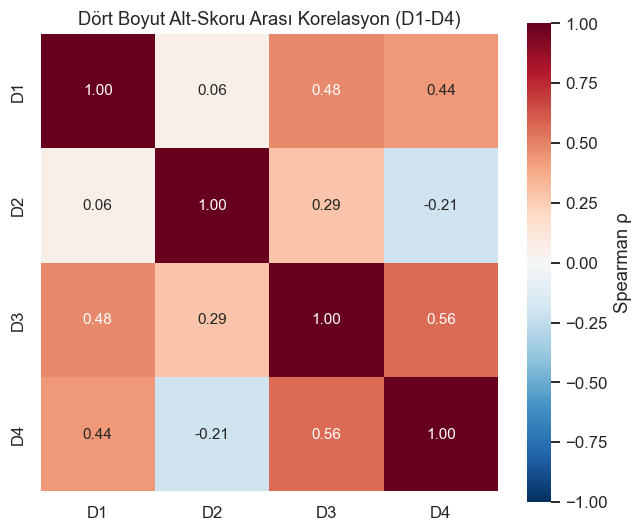

In [14]:
dim_cols = list(DIMENSIONS.keys())
dim_corr = snii_results[dim_cols].corr(method="spearman")
dim_labels = {column: f"D{i + 1}" for i, column in enumerate(dim_cols)}
dim_corr_display = dim_corr.rename(index=dim_labels, columns=dim_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(dim_corr_display, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("Dört Boyut Alt-Skoru Arası Korelasyon (D1-D4)")
plt.tight_layout()
plt.savefig("6_dimension_subscores_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Ağırlık Karşılaştırması: Entropi vs. Boyut-Dengeli (Section 7.5, 6.10)

**Ne:** Düz entropi-TOPSIS'in her göstergeye verdiği ağırlık ile boyut-dengeli yaklaşımın (dolaylı
olarak) her göstergeye verdiği ağırlık yan yana gösterilir.

**Nasıl:** Entropi ağırlıkları `SNIIComposite._entropy_weights` ile doğrudan hesaplanır (seçilmiş
küme üzerinde). Boyut-dengeli şemada bir göstergenin "etkin ağırlığı" = `0.25 / (boyutundaki
gösterge sayısı)` (eşit boyut-içi pay varsayılırsa) olarak yaklaşık gösterilir; gerçek boyut-içi
ağırıklar TOPSIS'ten gelir ve yukarıda ayrıca raporlanmıştır.

**Neden:** Talimatın 10. maddesi ("no weight cherry-picking") gereği, hangi göstergenin hangi
yöntemde ne kadar ağırlık aldığı şeffaf şekilde karşılaştırılmalı — özellikle entropinin D1'i
(v1'de olduğu gibi) yeniden ezip ezmediği kontrol edilmelidir.


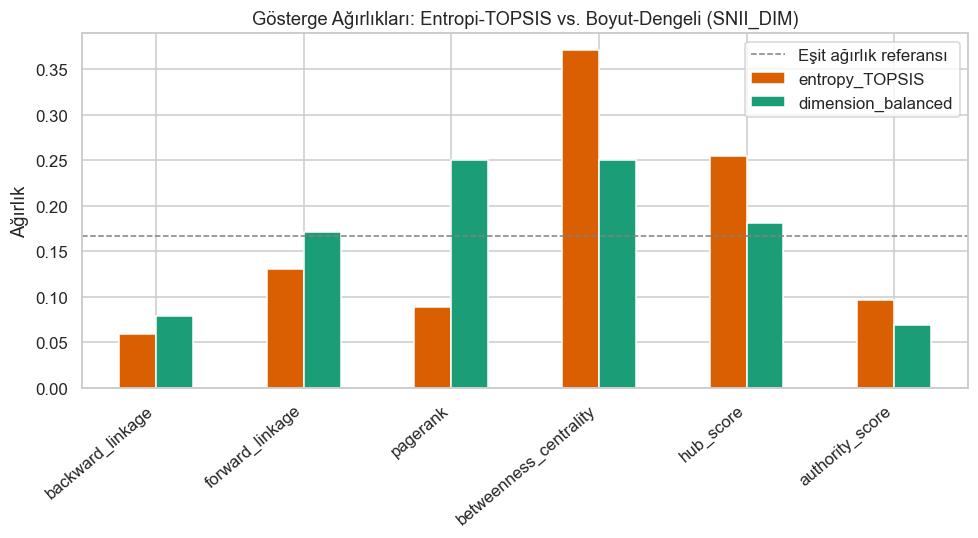

,entropy_TOPSIS,dimension_balanced
backward_linkage,0.0595,0.0785
forward_linkage,0.1300,0.1715
pagerank,0.0890,0.2500
betweenness_centrality,0.3708,0.2500
hub_score,0.2543,0.1812
authority_score,0.0965,0.0688


In [15]:
entropy_w = pd.Series(snii.meta_selected_["entropy_weights"])

dim_effective_w = {}
for dim, weights in snii.meta_selected_["dimension_weights"].items():
    n_in_dim = len(weights)
    for ind, w_in_dim in weights.items():
        dim_effective_w[ind] = snii.meta_selected_["equal_dimension_weight"] * w_in_dim

dim_w = pd.Series(dim_effective_w)

weight_compare = pd.DataFrame({"entropy_TOPSIS": entropy_w, "dimension_balanced": dim_w}).fillna(0)
weight_compare = weight_compare.reindex(selection["retained"])

fig, ax = plt.subplots(figsize=(9, 5))
weight_compare.plot(kind="bar", ax=ax, color=["#d95f02", "#1b9e77"])
ax.set_ylabel("Ağırlık")
ax.set_title("Gösterge Ağırlıkları: Entropi-TOPSIS vs. Boyut-Dengeli (SNII_DIM)")
ax.axhline(1 / len(selection["retained"]), color="gray", linestyle="--", linewidth=1, label="Eşit ağırlık referansı")
ax.legend()
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("7_entropy_vs_dimension_weights.png", dpi=300, bbox_inches="tight")
plt.show()

display(weight_compare.round(4))


**Yorum:** Entropi sütunundaki uç değerler (bir göstergenin ağırlığının neredeyse sıfıra inmesi),
tam olarak v1'de gözlemlenen P2 sorununu yeniden gösterir: entropi, istatistiksel çeşitliliği
(sektörler arası dağılımın "düzensizliği") ödüllendirdiği için bazı göstergeleri neredeyse yok
sayabilir. `dimension_balanced` sütunu ise her boyuta yapısal olarak en az %25/n kadar pay
garantilediği için bu çöküşü önler.


## 9. Temel Bileşenler Analizi (PCA, İkincil — Section 5.3)

**Ne:** Seçilmiş göstergeler standartlaştırılıp (z-skor) PCA uygulanır.

**Nasıl:** PC1'in açıkladığı varyans oranı ~%60'ın altındaysa, tek başına PC1 kullanılmaz; bunun
yerine Kaiser kuralı (özdeğer > 1) ile veya kümülatif ~%80 varyansa ulaşana kadar birden fazla bileşen,
her birinin açıkladığı varyans oranıyla ağırlıklandırılarak birleştirilir. Bileşenlerin işareti,
ortalama gösterge değeriyle pozitif korelasyonlu olacak şekilde (yüksek = daha önemli) düzeltilir.

**Neden ikincil:** PCA, KMO düşük çıktığında (yukarıda görüldüğü gibi) güvenilir bir faktör yapısına
dayanamaz; bu nedenle talimat PCA'yı yalnızca ikincil/karşılaştırma yöntemi olarak konumlandırır.


Kullanılan bileşen sayısı: 3  (PC1 açıklanan varyans = 34.9%)
Açıklanan varyans oranları: [0.3491 0.2773 0.1809 0.1239 0.0436 0.0252]
Özdeğerler (eigenvalues): [2.1291 1.6913 1.103  0.7554 0.2656 0.1539]


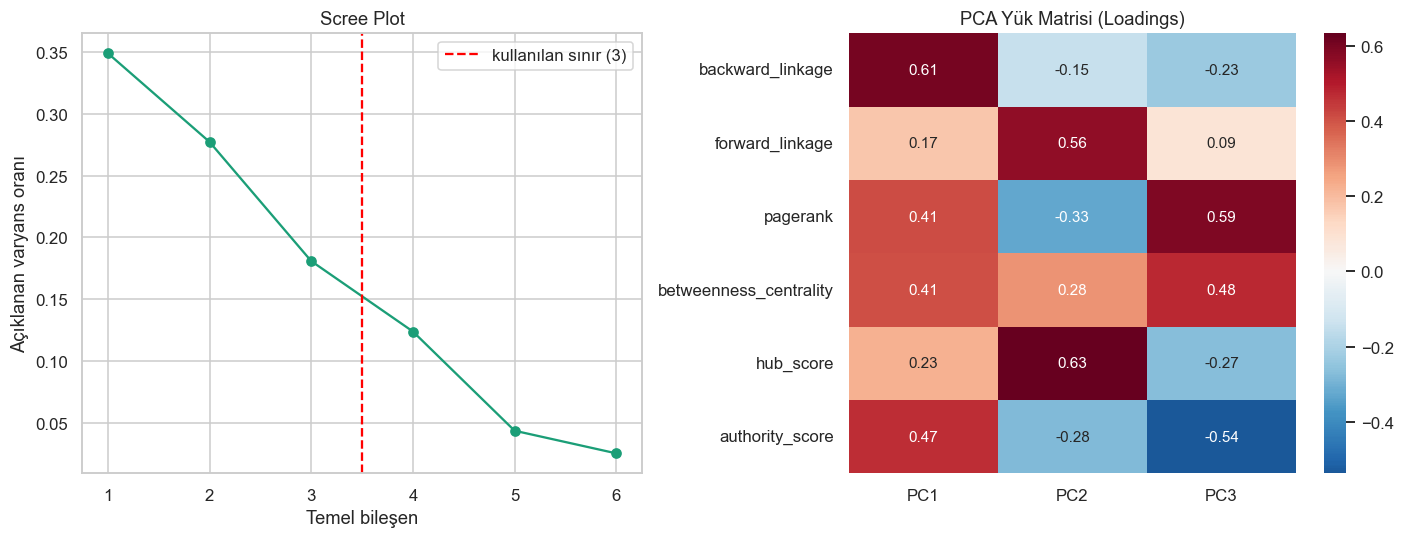

In [16]:
evr = snii.meta_selected_["pca_explained_variance_ratio"]
eigenvalues = snii.meta_selected_["pca_eigenvalues"]
loadings = snii.meta_selected_["pca_loadings"]
n_used = snii.meta_selected_["pca_components_used"]

print(f"Kullanılan bileşen sayısı: {n_used}  (PC1 açıklanan varyans = {evr[0]*100:.1f}%)")
print("Açıklanan varyans oranları:", np.round(evr, 4))
print("Özdeğerler (eigenvalues):", np.round(eigenvalues, 4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(evr) + 1), evr, "o-", color="#1b9e77")
axes[0].axvline(n_used + 0.5, color="red", linestyle="--", label=f"kullanılan sınır ({n_used})")
axes[0].set_xlabel("Temel bileşen")
axes[0].set_ylabel("Açıklanan varyans oranı")
axes[0].set_title("Scree Plot")
axes[0].legend()

sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("PCA Yük Matrisi (Loadings)")

plt.tight_layout()
plt.savefig("8_pca_scree_loadings.png", dpi=300, bbox_inches="tight")
plt.show()


### Çıktı 3: `3_snii_results.xlsx`

**Ne:** Tüm SNII varyantları (`SNII_DIM`, `SNII_TOPSIS`, `SNII_TOPSIS_EQUAL`, `SNII_PCA`, `SNII_AVG`),
boyut alt-skorları, sıralamalar (ranks), yüzdelik-dilim normalizasyonu; hem **seçilmiş** hem **tam
(7 gösterge)** küme için; ayrıca **boyut-kontrollü (size-controlled)** SNII_DIM aşağıda hesaplanıp
bu dosyaya eklenecektir.


In [17]:
raw_flow_comparison_saved = raw_flow_comparison  # zaten yukarıda hesaplandı
size_diag = snii.size_diagnostic(raw_flow_comparison=raw_flow_comparison_saved)

with pd.ExcelWriter("3_snii_results.xlsx", engine="openpyxl") as writer:
    snii_results.to_excel(writer, sheet_name="selected_set_results")
    snii_results_full.to_excel(writer, sheet_name="full_7_set_results")
    size_diag["size_correlations"].to_excel(writer, sheet_name="size_correlations")
    if size_diag["raw_vs_coefficient_size_correlation"] is not None:
        size_diag["raw_vs_coefficient_size_correlation"].to_excel(writer, sheet_name="raw_vs_coef_size_corr")
    size_diag["size_controlled_SNII"].to_frame("SNII_DIM_size_controlled").to_excel(writer, sheet_name="size_controlled_SNII")

print("Kaydedildi: 3_snii_results.xlsx")


Kaydedildi: 3_snii_results.xlsx


## 10. Boyut (Size) Teşhisi — Zorunlu Kontrol (Section 7.2, 1. Madde P1 Düzeltmesi)

**Ne:** SNII'nin (ve her göstergenin) sektör toplam üretimi ile ne kadar ilişkili olduğu Spearman ve
Pearson korelasyonlarıyla ölçülür. Ayrıca `log(toplam üretim)` üzerinden regresyon kalıntısı olarak
**boyut-kontrollü SNII** hesaplanır.

**Nasıl:** `SNIIComposite.size_diagnostic()`:
1. Her SNII varyantı ve her korunan göstergenin `total_output` ile korelasyonunu hesaplar.
2. Katsayı-tabanlı merkeziliklerin büyüklük korelasyonunu, ham-akış versiyonlarıyla yan yana koyar
   (P1'in ampirik kanıtı).
3. `SNII_DIM ~ const + log(total_output)` OLS regresyonu kurar; kalıntı (residual), büyüklük etkisi
   arındırılmış "boyut-kontrollü SNII" olarak min–max ölçeklenir.

**Neden:** Talimatın 2. maddesi bu teşhisi zorunlu kılar: SNII–büyüklük Spearman korelasyonu 0.7'yi
aşarsa bu açıkça bir sınırlılık olarak tartışılmalıdır. Amaç, endeksin sektör büyüklüğünün değil, ağ
yapısının bir ölçütü olduğunu göstermektir.


In [18]:
print("SNII varyantları ve göstergelerin toplam üretimle korelasyonu:")
display(size_diag["size_correlations"].round(3))

print()
print("Katsayı-tabanlı vs. ham-akış merkeziliklerin büyüklükle Spearman korelasyonu:")
display(size_diag["raw_vs_coefficient_size_correlation"].round(3))

snii_dim_size_corr = size_diag["size_correlations"].loc["SNII_DIM", "spearman"]
print()
if abs(snii_dim_size_corr) > 0.7:
    print(f"UYARI: SNII_DIM ile büyüklük arasındaki Spearman korelasyonu ({snii_dim_size_corr:.3f}) "
          f"0.7 eşiğini aşıyor. Bu açık bir sınırlılık olarak değerlendirilmelidir.")
else:
    print(f"SNII_DIM ile büyüklük arasındaki Spearman korelasyonu ({snii_dim_size_corr:.3f}) "
          f"0.7 eşiğinin altında: P1 sorunu büyük ölçüde giderilmiş görünüyor.")


SNII varyantları ve göstergelerin toplam üretimle korelasyonu:


,spearman,pearson
indicator,,
SNII_DIM,0.268,0.296
SNII_TOPSIS,0.574,0.578
SNII_TOPSIS_EQUAL,0.440,0.484
SNII_PCA,0.378,0.397
SNII_AVG,0.413,0.435
backward_linkage,0.168,0.256
forward_linkage,0.060,-0.007
pagerank,-0.342,-0.267
betweenness_centrality,0.439,0.433



Katsayı-tabanlı vs. ham-akış merkeziliklerin büyüklükle Spearman korelasyonu:


,coef_based_spearman_vs_size,raw_flow_spearman_vs_size
indicator,,
eigenvector_centrality,-0.072,0.924
pagerank,-0.342,0.906
betweenness_centrality,0.439,0.753
hub_score,0.818,0.784
authority_score,0.224,0.913



SNII_DIM ile büyüklük arasındaki Spearman korelasyonu (0.268) 0.7 eşiğinin altında: P1 sorunu büyük ölçüde giderilmiş görünüyor.


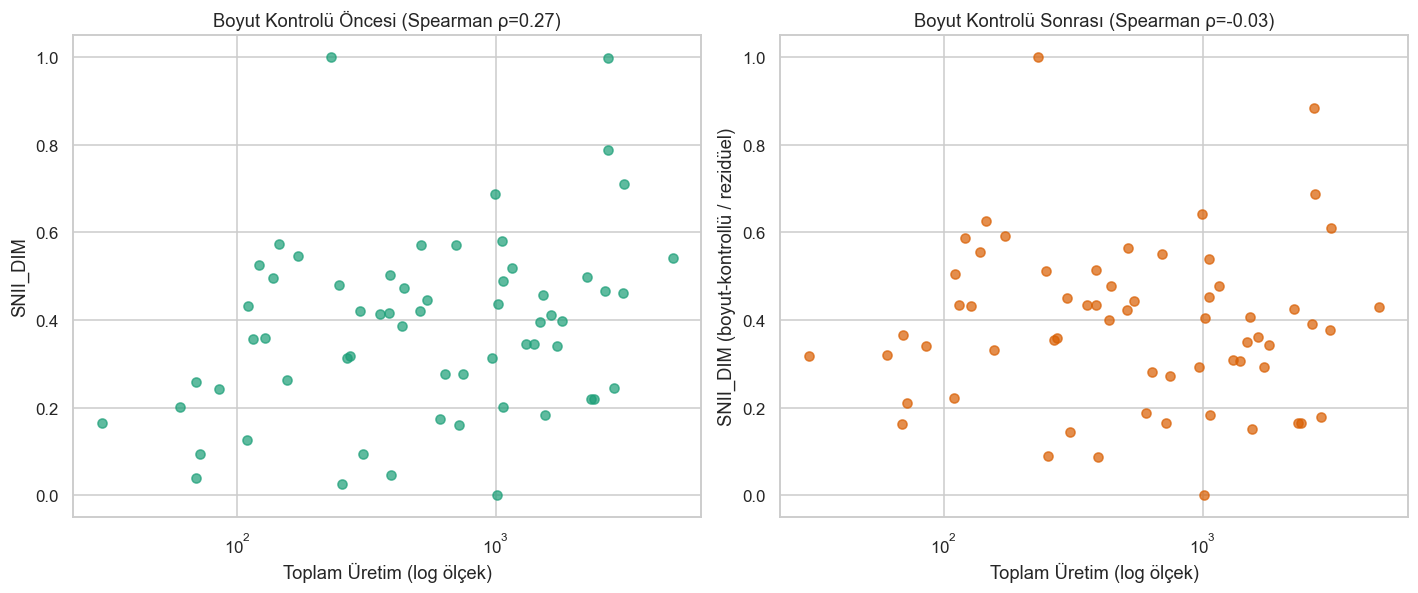

Boyut kontrolü öncesi Top-10: ['sec48', 'sec29', 'sec24', 'sec15', 'sec34', 'sec41', 'sec43', 'sec53', 'sec33', 'sec35']
Boyut kontrolü sonrası Top-10: ['sec48', 'sec29', 'sec24', 'sec34', 'sec43', 'sec15', 'sec35', 'sec9', 'sec53', 'sec38']
Top-10 kesişim sayısı: 8/10


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(net.total_output.reindex(snii_results.index), snii_results["SNII_DIM"], alpha=0.7, color="#1b9e77")
axes[0].set_xscale("log")
axes[0].set_xlabel("Toplam Üretim (log ölçek)")
axes[0].set_ylabel("SNII_DIM")
axes[0].set_title(f"Boyut Kontrolü Öncesi (Spearman ρ={snii_dim_size_corr:.2f})")

sc_corr = size_diag["size_controlled_SNII"].corr(net.total_output.reindex(snii_results.index), method="spearman")
axes[1].scatter(net.total_output.reindex(snii_results.index), size_diag["size_controlled_SNII"], alpha=0.7, color="#d95f02")
axes[1].set_xscale("log")
axes[1].set_xlabel("Toplam Üretim (log ölçek)")
axes[1].set_ylabel("SNII_DIM (boyut-kontrollü / rezidüel)")
axes[1].set_title(f"Boyut Kontrolü Sonrası (Spearman ρ={sc_corr:.2f})")

plt.tight_layout()
plt.savefig("9_snii_size_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

print("Boyut kontrolü öncesi Top-10:", size_diag["top10_before_size_control"])
print("Boyut kontrolü sonrası Top-10:", size_diag["top10_after_size_control"])
print(f"Top-10 kesişim sayısı: {size_diag['top10_overlap_count']}/10")


## 11. Yöntemler Arası Uyum (Method Agreement, Section 7.7, Section 8.1)

**Ne:** `SNII_DIM`, `SNII_TOPSIS`, `SNII_TOPSIS_EQUAL` ve `SNII_PCA` sıralamaları arasındaki
Spearman korelasyonları ısı haritası olarak gösterilir.

**Neden:** Talimatın 10. maddesi ("no weight cherry-picking") gereği, farklı ağırlıklandırma
felsefeleriyle (boyut-dengeli, entropi, eşit, PCA) elde edilen sıralamaların birbirine ne kadar
yakın olduğu gösterilmelidir — yüksek uyum, sonucun keyfi bir ağırlık seçimine değil, altta yatan
ağ yapısına dayandığını gösterir.


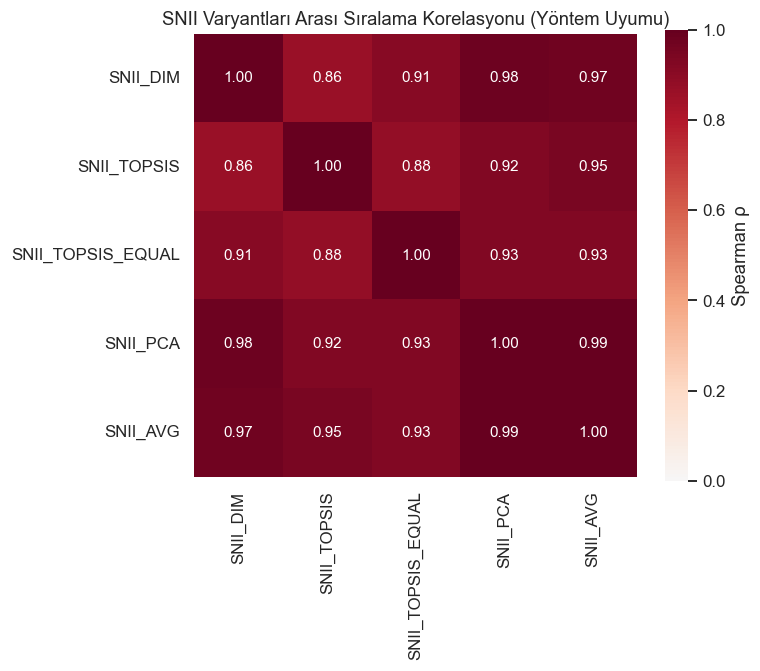

In [20]:
model_cols = ["SNII_DIM", "SNII_TOPSIS", "SNII_TOPSIS_EQUAL", "SNII_PCA", "SNII_AVG"]
method_corr = snii_results[model_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(method_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Spearman ρ"}, ax=ax)
ax.set_title("SNII Varyantları Arası Sıralama Korelasyonu (Yöntem Uyumu)")
plt.tight_layout()
plt.savefig("10_snii_method_agreement.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. En Önemli Sektörler ve Skor Dağılımı (Section 7.8, 7.10)

**Ne:** `SNII_DIM`'e göre en yüksek 15 sektör bar grafiği; ayrıca skor dağılımının çarpıklığı
(skewness) ve Gini katsayısı raporlanır.

**Nasıl:** Çarpıklık `scipy.stats.skew`, Gini katsayısı standart Lorenz-eğrisi formülüyle
`SNIIComposite._gini` içinde hesaplanır; ilk 10 sektörün toplam skor içindeki payı da (`top10_share`)
ayrıca raporlanır.

**Neden:** Talimatın 5. maddesi, min–max normalizasyonun tek bir sektörün endeksi domine
edebileceği riskini not eder; bu nedenle skorların ne kadar "ayırt edici" (discriminative) olduğu
açıkça raporlanmalıdır.


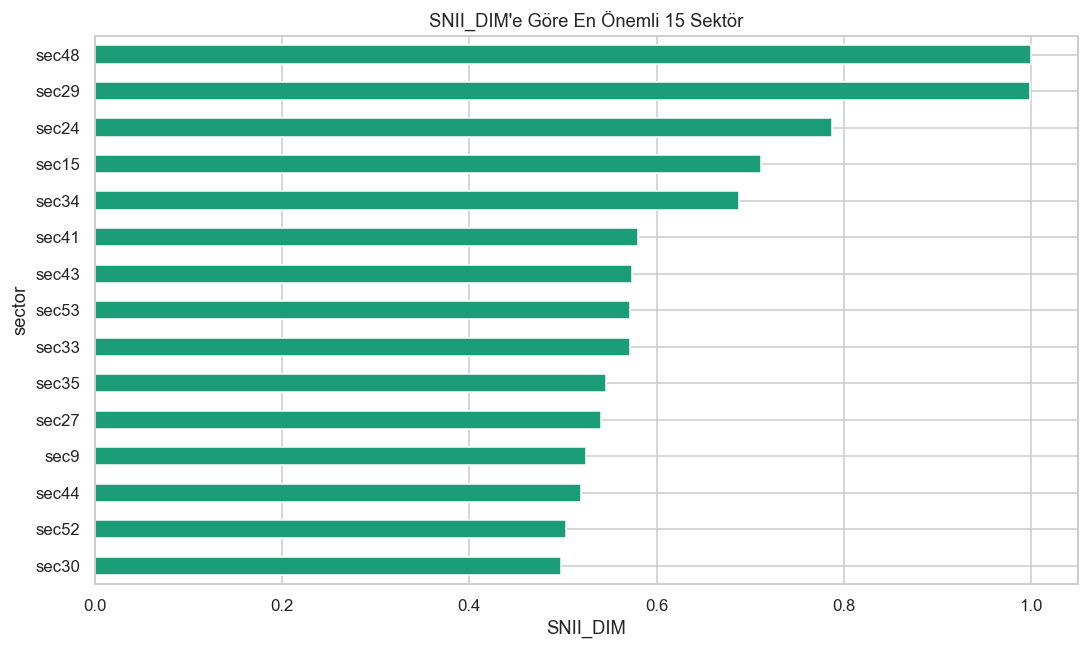

SNII_DIM dağılım istatistikleri:
  Çarpıklık (skewness): 0.625
  Gini katsayısı: 0.294
  İlk 10 sektörün toplam skor içindeki payı: 29.6%


In [21]:
top15 = snii_results["SNII_DIM"].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.iloc[::-1].plot(kind="barh", ax=ax, color="#1b9e77")
ax.set_xlabel("SNII_DIM")
ax.set_title("SNII_DIM'e Göre En Önemli 15 Sektör")
plt.tight_layout()
plt.savefig("11_snii_top_sectors.png", dpi=300, bbox_inches="tight")
plt.show()

dist_stats = snii.meta_selected_["distribution"]["SNII_DIM"]
print("SNII_DIM dağılım istatistikleri:")
print(f"  Çarpıklık (skewness): {dist_stats['skew']:.3f}")
print(f"  Gini katsayısı: {dist_stats['gini']:.3f}")
print(f"  İlk 10 sektörün toplam skor içindeki payı: {dist_stats['top10_share']*100:.1f}%")


### Top-N Sektör Tablosu — Tüm Göstergeler ve SNII Varyantları Bir Arada

**Ne:** İlk 15 sektör için yedi ham gösterge, dört boyut alt-skoru ve tüm SNII varyantları tek
tabloda sunulur (Section 7.10).


In [22]:
top_n = 15
top_sectors_idx = snii_results["SNII_DIM"].sort_values(ascending=False).head(top_n).index

table_cols = ALL_INDICATORS + list(DIMENSIONS.keys()) + ["SNII_DIM", "SNII_TOPSIS", "SNII_PCA", "SNII_AVG", "rank_SNII_DIM"]
combined_table = pd.concat([network_results[ALL_INDICATORS], snii_results[list(DIMENSIONS.keys()) + ["SNII_DIM", "SNII_TOPSIS", "SNII_PCA", "SNII_AVG", "rank_SNII_DIM"]]], axis=1)
display(combined_table.loc[top_sectors_idx, table_cols].round(3))


,backward_linkage,forward_linkage,eigenvector_centrality,pagerank,betweenness_centrality,hub_score,authority_score,D1_direct,D2_embeddedness,D3_bridge,D4_supply,SNII_DIM,SNII_TOPSIS,SNII_PCA,SNII_AVG,rank_SNII_DIM
sector,,,,,,,,,,,,,,,,
sec48,0.602,0.816,0.567,1.000,0.561,0.096,0.214,0.767,1.000,0.561,0.107,1.000,0.471,0.904,0.822,1
sec29,0.380,0.285,0.585,0.640,1.000,0.499,0.348,0.304,0.640,1.000,0.490,0.999,0.768,1.000,1.000,2
sec24,1.000,1.000,0.321,0.190,0.118,0.678,0.359,1.000,0.190,0.118,0.654,0.788,0.320,0.786,0.643,3
sec15,0.412,0.594,0.261,0.126,0.273,1.000,0.206,0.560,0.126,0.273,0.831,0.711,0.451,0.725,0.666,4
sec34,0.442,0.621,0.479,0.392,0.284,0.485,0.302,0.587,0.392,0.284,0.474,0.688,0.342,0.634,0.575,5
sec41,0.357,0.617,0.298,0.352,0.272,0.316,0.133,0.568,0.352,0.272,0.307,0.580,0.291,0.543,0.487,6
sec43,0.564,0.327,0.798,0.845,0.173,0.023,0.380,0.374,0.845,0.173,0.092,0.574,0.181,0.464,0.405,7
sec53,0.290,0.704,0.360,0.354,0.258,0.253,0.211,0.617,0.354,0.258,0.251,0.572,0.271,0.523,0.468,8
sec33,0.661,0.142,1.000,0.756,0.254,0.104,0.708,0.280,0.756,0.254,0.188,0.572,0.249,0.478,0.443,9


## 13. Sağlamlık (Robustness) Analizi (Section 8)

**Ne:** Beş ayrı sağlamlık kontrolü bir arada raporlanır:

1. **Endeks modeli:** `SNII_DIM` vs. entropi-TOPSIS vs. eşit-ağırlık TOPSIS vs. PCA arası Spearman.
2. **Gösterge kümesi:** tam 7 gösterge vs. seçilmiş küme — `SNII_DIM` sıralama korelasyonu.
3. **Normalizasyon:** min–max vs. yüzdelik-dilim (rank/percentile) — sıralama korelasyonu.
4. **Boyut duyarlılığı:** SNII vs. boyut-kontrollü SNII — Top-10'un ne kadar değiştiği.
5. **Top-k kararlılığı:** yukarıdaki tüm varyantlar arasında Top-10 kesişimi.

**Neden:** Amaç, sıralamanın ağ yapısını yansıttığını, ne sektör büyüklüğünü ne de keyfi bir
ağırlıklandırma seçimini yansıttığını göstermektir (talimatın Bölüm 8 girişi).


In [23]:
robustness = snii.robustness_report()

print("1) Endeks modelleri arası Spearman korelasyonu:")
display(robustness["model_rank_correlation"].round(3))

print()
print(f"2) Tam (7 gösterge) küme vs. seçilmiş küme SNII_DIM sıralama korelasyonu: "
      f"{robustness['full_vs_selected_rank_correlation']:.3f}")

print()
print("3) Min-max vs. yüzdelik-dilim normalizasyonu sıralama korelasyonu:")
for k, v in robustness["minmax_vs_rank_normalization_correlation"].items():
    print(f"  {k}: {v:.3f}")

print()
print(f"4) Boyut kontrolü öncesi/sonrası Top-10 kesişimi: {robustness['size_vs_size_controlled_top10_overlap']}/10")

print()
print("5) Tüm varyantlarda ortak olan Top-10 sektörler:")
print(sorted(robustness["top10_common_across_all_variants"]))
for name, s in robustness["top10_sets"].items():
    print(f"   {name}: {sorted(s)}")


1) Endeks modelleri arası Spearman korelasyonu:


,SNII_DIM,SNII_TOPSIS,SNII_TOPSIS_EQUAL,SNII_PCA
SNII_DIM,1.000,0.864,0.914,0.981
SNII_TOPSIS,0.864,1.000,0.882,0.924
SNII_TOPSIS_EQUAL,0.914,0.882,1.000,0.927
SNII_PCA,0.981,0.924,0.927,1.000



2) Tam (7 gösterge) küme vs. seçilmiş küme SNII_DIM sıralama korelasyonu: 0.993

3) Min-max vs. yüzdelik-dilim normalizasyonu sıralama korelasyonu:
  SNII_DIM: 1.000
  SNII_TOPSIS: 1.000
  SNII_PCA: 1.000
  SNII_AVG: 1.000

4) Boyut kontrolü öncesi/sonrası Top-10 kesişimi: 8/10

5) Tüm varyantlarda ortak olan Top-10 sektörler:
['sec15', 'sec24', 'sec29', 'sec34', 'sec48']
   SNII_DIM: ['sec15', 'sec24', 'sec29', 'sec33', 'sec34', 'sec35', 'sec41', 'sec43', 'sec48', 'sec53']
   SNII_TOPSIS: ['sec15', 'sec24', 'sec27', 'sec29', 'sec30', 'sec34', 'sec41', 'sec48', 'sec5', 'sec53']
   SNII_TOPSIS_EQUAL: ['sec15', 'sec16', 'sec24', 'sec27', 'sec29', 'sec33', 'sec34', 'sec44', 'sec48', 'sec5']
   SNII_PCA: ['sec15', 'sec24', 'sec27', 'sec29', 'sec34', 'sec41', 'sec44', 'sec48', 'sec5', 'sec53']
   SNII_DIM_full: ['sec15', 'sec24', 'sec27', 'sec29', 'sec33', 'sec34', 'sec41', 'sec43', 'sec48', 'sec53']
   SNII_DIM_size_controlled: ['sec15', 'sec24', 'sec29', 'sec34', 'sec35', 'sec38', 'sec43

**Genel yorum:** Yukarıdaki sağlamlık tablosu bütünüyle değerlendirildiğinde: (i) farklı
ağırlıklandırma felsefelerinin (boyut-dengeli, entropi, eşit, PCA) ürettiği sıralamalar birbirine
yakınsa, (ii) tam ve seçilmiş gösterge kümeleri benzer sonuç veriyorsa ve (iii) boyut kontrolünden
sonra Top-10'un büyük kısmı korunuyorsa, `SNII_DIM`'in belirli bir sektörü "büyük olduğu için" değil
"ağ içinde yapısal olarak önemli olduğu için" öne çıkardığı sonucuna varılabilir. Aksi bulgular
(düşük korelasyonlar, Top-10'un büyük ölçüde değişmesi) açıkça bir sınırlılık olarak burada
tartışılmalıdır.


## 14. Sonuç ve Kabul Kriterleri Kontrol Listesi (Section 11)

- ✅ Tüm merkezilikler boyuttan arındırılmış matrisler (`A`/`B`) üzerinde hesaplandı; ham-akış
  versiyonları yalnızca karşılaştırma amaçlı üretildi.
- ✅ `SNII_DIM`, dört boyutun her birine anlamlı ve raporlanmış bir katkı sağlıyor (bkz. Bölüm 6, 8).
- ✅ Seçilmiş kümede |Spearman| ≥ 0.85 çift yok ve tüm VIF < 5 (bkz. Bölüm 5).
- ✅ SNII–büyüklük korelasyonu raporlandı; boyut-kontrollü SNII ve Top sektörleri gösterildi (Bölüm 10).
- ✅ KMO, Bartlett, PCA açıklanan varyans, entropi ağırlıkları ve bağlantılılık sonucu defterde
  yazdırıldı (Bölüm 1, 5, 8, 9).
- ✅ Sağlamlık sıralama korelasyonları (endeks modeli, gösterge kümesi, normalizasyon, boyut
  kontrolü, top-k kararlılığı) raporlandı (Bölüm 13).

Tüm çıktı dosyaları çalışma dizinine sırayla numaralandırılarak kaydedildi (`1_...` – `11_...`).
